In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise
using JJDFTX: fermi, bose, diagonalize_phonon
using HCubature

  Activating project at `~/Github_Projects/JJDFTX.jl`


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [2]:
using PyPlot, PyCall, Statistics, JJDFTX, LinearAlgebra;
#using Peaks;
interpolate = pyimport("scipy.interpolate").interp1d;

In [3]:
total = zeros(200)
new_self_energy = zeros(200, 200)
for i in 1:200
    b = np.loadtxt("./self_energy_3/revisit_after_a_year/self_energy-$i.txt")
    a = np.loadtxt("./self_energy_3/revisit_after_a_year/self_energy-nums-$i.txt")
    total += a
    new_self_energy += b
end

### The plot below should resemble the density of states of graphene

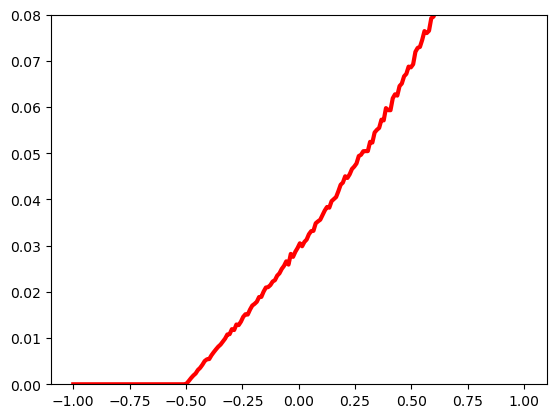

In [17]:
plot(range(-1, 1, length=200), total./200*100/9, color="red", linewidth=3)
ylim(0, 0.1)
ylim(0, 0.08);

In [6]:
self_energy = replace(new_self_energy ./ np.repeat(np.reshape(total, (200, 1)), 200, axis=1), NaN=>0);

In [10]:
N = 100
Nprime = 1000
plot_len = 100
omegas3 = collect(range(-1, 1, length=2*N));
omegas4 = collect(range(-1, 1, length=2*Nprime));
tau_invs3 = zeros(plot_len)
fomegas = fermi.(omegas3, 1);
win_len = 20
delta = 0
for (i, omega) in enumerate(range(0.01, 1, length=plot_len))
    if (i % 10) == 0
        println("Current frequency:, $omega"); flush(stdout)
    end
    fomegaprimes = fermi.(omegas3 .+ omega, 1);
    omega_idx = round(Int, omega * N)
    tau_inv = 0
    for idx2 in 1:length(omegas4)
        epsilon = omegas4[idx2]
        self_energy_idx = argmin(abs.(epsilon .- omegas3))
        self_energy_epsilon = smooth(self_energy[self_energy_idx, :], win_len=win_len)
        dos_term = total[self_energy_idx] / total[100]
        iszero(dos_term) && continue
        for idx in 1:(2*N-omega_idx)
            omegaprime = omegas3[idx]
            A1 = imag(1/(omega+omegaprime-epsilon+1im*delta+1im*self_energy_epsilon[idx+omega_idx]))
            A2 = imag(1/(omegaprime-epsilon+1im*delta+1im*self_energy_epsilon[idx]))
            tau_inv_add = dos_term * (omega/pi) * (1/N) * (1/Nprime) * (-fomegaprimes[idx] + fomegas[idx])*A1*A2
            isnan(tau_inv_add) && (println("omegaprime: $omegaprime, epsilon: $epsilon, omegaplusomegaprime: $(omega+omegaprime)"))
            tau_inv += tau_inv_add
        end
    end
    tau_invs3[i] = tau_inv
end

Current frequency:, 0.1
Current frequency:, 0.2
Current frequency:, 0.3
Current frequency:, 0.4
Current frequency:, 0.5
Current frequency:, 0.6
Current frequency:, 0.7
Current frequency:, 0.8
Current frequency:, 0.9
Current frequency:, 1.0


In [11]:
taus3 = (10^15)*(ħ ./ tau_invs3);

In [13]:
tau_allen_inv = zeros(100)
N = 200
idx = 1
for i in idx:idx+N-1
    tau_allen_inv += (1/N)*(1 ./ (np.loadtxt("boltzmann/boltzmann-$i.txt")))
end
tau_allen = 1 ./ tau_allen_inv;

In [18]:
x = 0
y = zeros(200)
nums = 0
for i in 1:200
    #a, b = [collect(x) for x in eachcol(np.loadtxt("./self_energy_finite_mu/self_energy-$i.txt"))] 
    b = np.loadtxt("./self_energy_2/self_energy-$i.txt")[:, 5]
    a = np.loadtxt("./self_energy_2/self_energy-nums-$i.txt")[5]
    y += b
    x += a 
    nums += a/200
end
sigmas2 = y ./ x;

In [19]:
omegas1 = collect(range(-1, 1, length=2000));
omegas2 = collect(range(-1, 1, length=200));
fomegas = fermi.(omegas1, 1);
tau_invs1 = zeros(100)
tau_invs2 = zeros(100)
N = 1000 #1000
fomegas = fermi.(omegas1, 1);
N = 100 #1000
fomegas = fermi.(omegas2, 1);
for (i, omega) in enumerate(range(0.01, 1, length=100))
    fomegaprimes = fermi.(omegas2 .+ omega, 1);
    omega_idx = round(Int, omega * N)
    tau_inv = 0
    for idx in 1:(2*N-omega_idx)
        tau_inv += omega * (1/N) * (fomegaprimes[idx] - fomegas[idx])*imag(1/(1im*sigmas2[idx]+1im*sigmas2[idx+omega_idx]+omega))
    end
    tau_invs2[i] = tau_inv
end
taus2 = (10^15)*(ħ ./ tau_invs2);

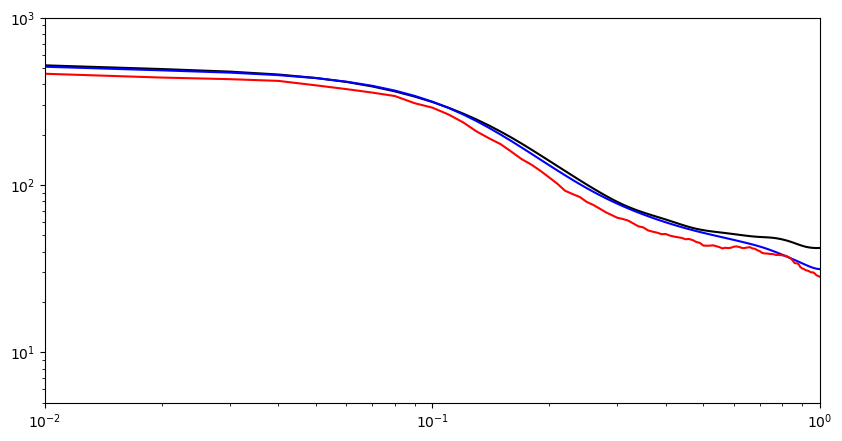

In [20]:
figure(figsize=(10, 5))
loglog(collect(0.01:0.01:1), smooth(taus3, win_len=1), color="black")
loglog(collect(0.01:0.01:1), smooth(taus2, win_len=1), color="blue")
loglog(collect(0.01:0.01:1), smooth(tau_allen, win_len=1), color="red")
ylim(5, 1000)
xlim(0.01, 1);